# Frame Description Visualization

This notebook helps visualize frames alongside their LLM-generated descriptions to verify quality.

In [1]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from PIL import Image
import datasets as hf_datasets
from typing import List, Dict, Tuple, Optional

from mmassist.datasets.generate.frame_utils import (
    load_frames_from_arrow,
    get_frame_at_timestamp,
    describe_frame_with_llm,
)
from mmassist.datasets.generate.openrouter_utils import LLMGenerator
from mmassist.datasets.generate.dialog_simulation import FRAME_DESCRIPTION_PROMPT
from mmassist.configs.arguments import DATA_ROOT_DIR

/u/swong2/.conda/envs/smolvlm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [10]:
DATA_ROOT_DIR = "/projects/beto/proassist_data"

# Paths
FRAMES_DIR = f"{DATA_ROOT_DIR}/processed_data/egoexo4d/frames"
ANNOTATIONS_DIR = f"{DATA_ROOT_DIR}/datasets/egoexo4d/annotations"

# Frame extraction parameters
FRAMES_FPS = 2.0

# LLM for frame descriptions
FRAME_DESC_LLM_MODEL = "google/gemini-2.5-pro"
# FRAME_DESC_LLM_MODEL = "google/gemini-2.5-flash"

## Load a Sample Video's Frames

In [11]:
# List available frame files
if os.path.exists(FRAMES_DIR):
    frame_files = [f for f in os.listdir(FRAMES_DIR) if f.endswith('.arrow')]
    print(f"Found {len(frame_files)} frame files")
    for i, f in enumerate(frame_files[:10]):
        print(f"{i}: {f}")
else:
    print(f"Frames directory not found: {FRAMES_DIR}")
    frame_files = []

Found 3331 frame files
0: upenn_0711_Cooking_6_4_downscaled_gp02.arrow
1: georgiatech_cooking_09_02_2_downscaled_cam05.arrow
2: uniandes_cooking_005_12_downscaled_cam01.arrow
3: iiith_cooking_25_3_downscaled_aria01_214-1.arrow
4: indiana_cooking_25_3_downscaled_cam03.arrow
5: iiith_cooking_89_4_downscaled_cam04.arrow
6: iiith_cooking_115_2_downscaled_aria01_214-1.arrow
7: iiith_cooking_130_4_downscaled_cam04.arrow
8: upenn_0702_Cooking_1_5_downscaled_gp01.arrow
9: sfu_cooking024_4_downscaled_cam04.arrow


In [12]:
# Select a frame file to visualize (change the index as needed)
if frame_files:
    selected_file_idx = 3  # Change this to select different videos
    selected_file = frame_files[selected_file_idx]
    arrow_path = os.path.join(FRAMES_DIR, selected_file)
    
    print(f"Loading frames from: {selected_file}")
    frames_data = load_frames_from_arrow(arrow_path)
    print(f"Loaded {len(frames_data)} frames")
else:
    print("No frame files available")
    frames_data = None

Loading frames from: iiith_cooking_25_3_downscaled_aria01_214-1.arrow
Loaded 224 frames


## Initialize Frame Description LLM

In [ ]:
os.environ["OPENROUTER_API_KEY"] = "asdf"


In [13]:
# Initialize the LLM for generating frame descriptions
print(f"Initializing LLM: {FRAME_DESC_LLM_MODEL}")
frame_desc_llm = LLMGenerator.build(model_id=FRAME_DESC_LLM_MODEL)
print("LLM initialized successfully")

Initializing LLM: google/gemini-2.5-pro
LLM initialized successfully


## Visualize Frames with Descriptions

In [14]:
def visualize_frame_with_description(
    frame: Image.Image,
    timestamp: float,
    description: str,
    ax=None,
    show: bool = True
):
    """Visualize a single frame with its description.
    
    Args:
        frame: PIL Image to display
        timestamp: Timestamp of the frame in seconds
        description: LLM-generated description
        ax: Matplotlib axis (if None, creates new figure)
        show: Whether to show the plot immediately
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Display the frame
    ax.imshow(frame)
    ax.axis('off')
    
    # Add title with timestamp
    ax.set_title(f"Timestamp: {timestamp:.1f}s", fontsize=14, fontweight='bold', pad=10)
    
    # Add description as text below the image
    wrapped_desc = '\n'.join([description[i:i+80] for i in range(0, len(description), 80)])
    ax.text(0.5, -0.05, wrapped_desc, 
            transform=ax.transAxes, 
            ha='center', 
            va='top',
            fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            wrap=True)
    
    if show:
        plt.tight_layout()
        plt.show()


def visualize_frames_grid(
    frames_with_descriptions: List[Tuple[Image.Image, float, str]],
    cols: int = 2,
    figsize_per_frame: Tuple[int, int] = (6, 5)
):
    """Visualize multiple frames with descriptions in a grid.
    
    Args:
        frames_with_descriptions: List of (frame, timestamp, description) tuples
        cols: Number of columns in the grid
        figsize_per_frame: Figure size per frame (width, height)
    """
    n = len(frames_with_descriptions)
    rows = (n + cols - 1) // cols
    
    fig = plt.figure(figsize=(figsize_per_frame[0] * cols, figsize_per_frame[1] * rows))
    gs = GridSpec(rows, cols, figure=fig, hspace=0.4, wspace=0.3)
    
    for i, (frame, timestamp, description) in enumerate(frames_with_descriptions):
        row = i // cols
        col = i % cols
        ax = fig.add_subplot(gs[row, col])
        
        visualize_frame_with_description(
            frame, timestamp, description, ax=ax, show=False
        )
    
    plt.tight_layout()
    plt.show()

In [15]:
# Generate descriptions for sample frames at different timestamps
# You can modify these timestamps to sample different moments in the video

if frames_data is not None:
    # Sample timestamps (in seconds) - adjust based on your video duration
    sample_timestamps = [5.0, 15.0, 30.0, 45.0, 60.0, 90.0]  # Modify as needed
    
    frames_with_descriptions = []
    
    print("Generating frame descriptions...")
    for timestamp in sample_timestamps:
        print(f"  Processing timestamp {timestamp}s...")
        
        # Get the frame at this timestamp
        frame = get_frame_at_timestamp(frames_data, timestamp, FRAMES_FPS)
        
        if frame is not None:
            # Generate description
            description = describe_frame_with_llm(frame, frame_desc_llm, FRAME_DESCRIPTION_PROMPT)
            print(f"    Description: {description}")
            
            frames_with_descriptions.append((frame, timestamp, description))
        else:
            print(f"    Warning: Frame not found at timestamp {timestamp}s")
    
    print(f"\nGenerated {len(frames_with_descriptions)} frame descriptions")
else:
    print("No frames data loaded")
    frames_with_descriptions = []

Generating frame descriptions...
  Processing timestamp 5.0s...
    Description: Chopped vegetables are sizzling in a stainless steel pan, appearing translucent with some browning on the edges. A wooden spatula is resting in the pan, and a visible amount of steam is rising, indicating active cooking on a heated surface.
  Processing timestamp 15.0s...
    Description: A stainless steel pan on the stove contains diced onions that are becoming translucent, with some edges starting to brown. Light steam is rising from the pan, and a wooden spoon is resting on the rim, indicating a potential pause in active stirring.
  Processing timestamp 30.0s...
    Description: A stainless steel pan on a lit stove contains chopped onions and peppers in shimmering oil. The onions appear translucent with slight browning on the edges, and a small amount of steam is rising. A wooden spoon rests inside the pan.
  Processing timestamp 45.0s...
    Description: A stainless steel pan on a lit burner contains c

/tmp/ipykernel_1681911/2565563969.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


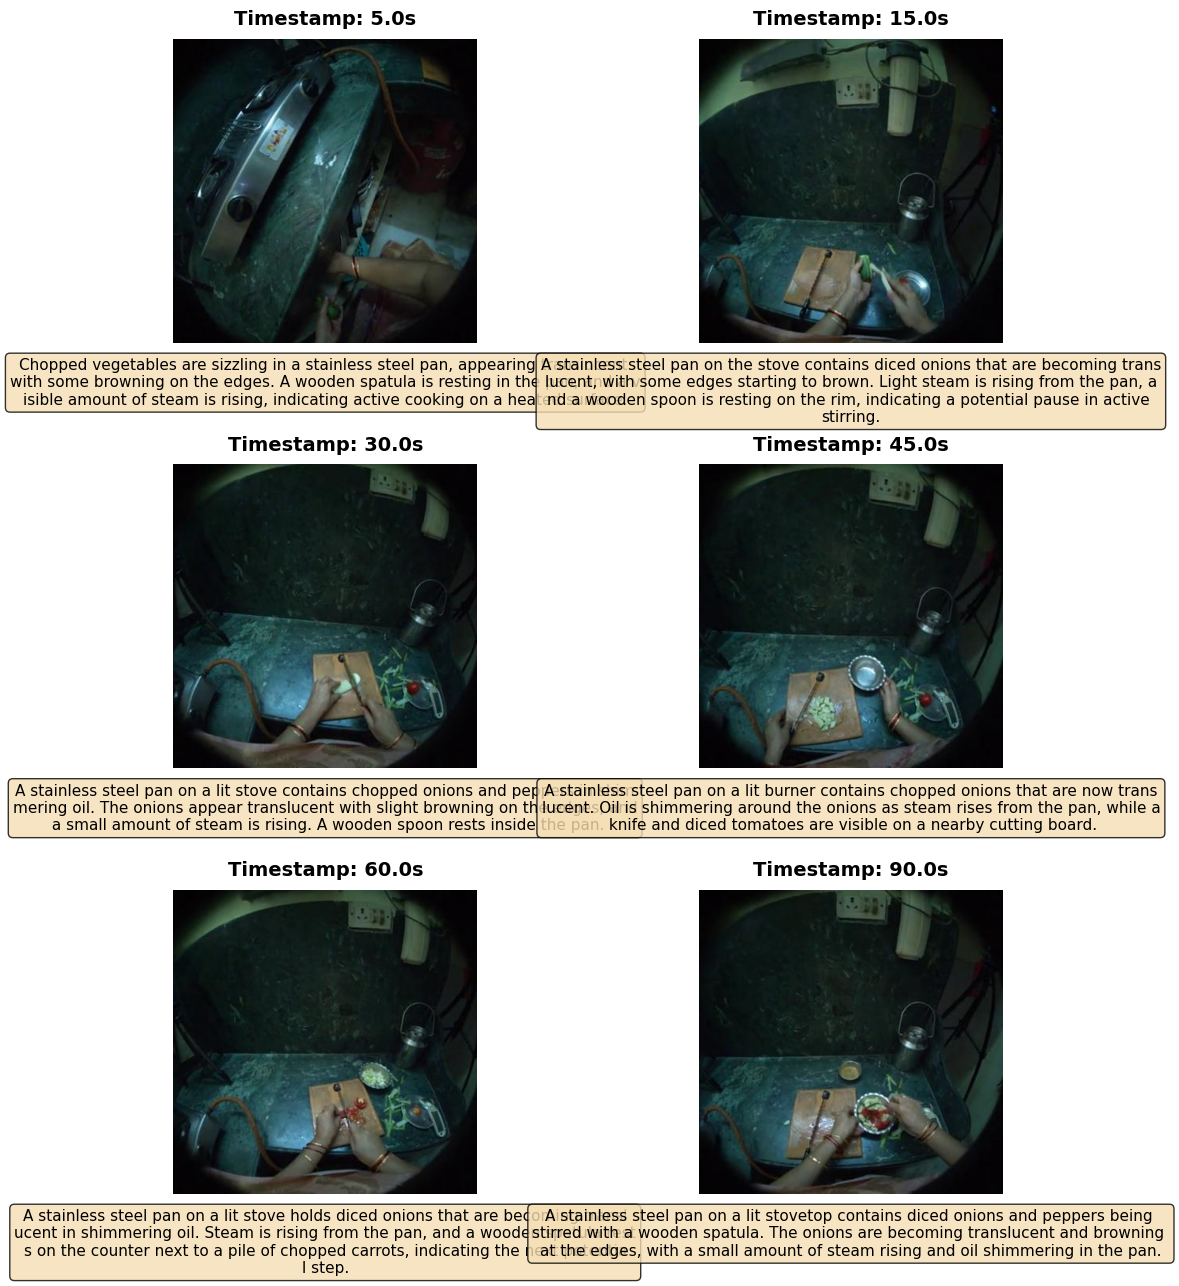

In [16]:
# Visualize all frames in a grid
if frames_with_descriptions:
    visualize_frames_grid(frames_with_descriptions, cols=2)
else:
    print("No frames to visualize")

## Load and Visualize Annotations with Frame Descriptions

This section loads actual annotations from a video and visualizes frames at annotation timestamps.

In [16]:
def load_atomic_annotations_for_take(take_uid: str, split: str = "train") -> List[Dict]:
    """Load atomic annotations for a specific take."""
    atomic_file = os.path.join(ANNOTATIONS_DIR, f"atomic_descriptions_{split}_filtered_longest.json")
    
    if not os.path.exists(atomic_file):
        print(f"Annotation file not found: {atomic_file}")
        return []
    
    with open(atomic_file, 'r') as f:
        atomic_data = json.load(f)
    
    if take_uid not in atomic_data.get('annotations', {}):
        print(f"No annotations found for take_uid: {take_uid}")
        return []
    
    take_annotation = atomic_data['annotations'][take_uid][0]
    
    # Filter out unsure annotations
    return [ann for ann in take_annotation["descriptions"] if not ann.get("unsure", False)]


def load_take_uid_to_take_name_mapping() -> Dict[str, str]:
    """Load mapping from take_uid to take_name."""
    takes_file = os.path.join(os.path.dirname(ANNOTATIONS_DIR), "takes.json")
    
    if not os.path.exists(takes_file):
        print(f"Takes file not found: {takes_file}")
        return {}
    
    with open(takes_file, 'r') as f:
        takes_data = json.load(f)
    
    return {take['take_uid']: take['take_name'] 
            for take in takes_data 
            if 'take_uid' in take and 'take_name' in take}


def find_aria_arrow_file(frames_dir: str, take_name: str) -> Optional[str]:
    """Find the Arrow file for a given take_name with aria camera."""
    if not os.path.exists(frames_dir):
        return None
    
    prefix = f"{take_name}_downscaled_"
    
    for filename in os.listdir(frames_dir):
        if filename.startswith(prefix) and "aria" in filename and filename.endswith(".arrow"):
            return os.path.join(frames_dir, filename)
    
    return None

In [17]:
# Load a specific take's annotations
# You can get take_uid from the atomic annotations file or specify one directly

# First, let's see what take_uids are available
split = "train"
atomic_file = os.path.join(ANNOTATIONS_DIR, f"atomic_descriptions_{split}_filtered_longest.json")

if os.path.exists(atomic_file):
    with open(atomic_file, 'r') as f:
        atomic_data = json.load(f)
    
    available_take_uids = list(atomic_data.get('annotations', {}).keys())
    print(f"Found {len(available_take_uids)} take_uids in {split} split")
    print("\nFirst 10 take_uids:")
    for i, uid in enumerate(available_take_uids[:10]):
        print(f"{i}: {uid}")
else:
    print(f"Annotation file not found: {atomic_file}")
    available_take_uids = []

Found 372 take_uids in train split

First 10 take_uids:
0: 086de81a-8989-4c62-b91c-9bd69bb1745d
1: 76de6c17-2b61-494b-ab32-39e97e1b40ed
2: e02bcacc-92af-4fe0-8c57-e42ff3f74dcf
3: 4a10d608-6712-4f08-aa69-1cfd4541dd6c
4: a9c72abf-f710-4854-8d9a-9ef98950eb24
5: ee0b1b43-6411-49d2-96ba-d06fa02760a9
6: 37b18db8-a85a-49dd-a594-68cb1dd5ed0e
7: ce9bec98-3ec5-4189-8f9d-03e3ff3cddda
8: bd58f048-87aa-4b40-97ee-17bdb2dd947e
9: 424d48e3-b2cc-4558-b9e8-f954f3a61f7a


In [ ]:
# Select a take_uid to visualize
if available_take_uids:
    selected_take_uid = available_take_uids[0]  # Change index to select different takes
    print(f"Selected take_uid: {selected_take_uid}")
    
    # Load annotations for this take
    annotations = load_atomic_annotations_for_take(selected_take_uid, split)
    print(f"\nLoaded {len(annotations)} atomic annotations")
    
    # Show first few annotations
    print("\nSample annotations:")
    for i, ann in enumerate(annotations[:5]):
        print(f"  [{ann['timestamp']:.1f}s] {ann['text']}")
    
    if len(annotations) > 5:
        print(f"  ... and {len(annotations) - 5} more")
else:
    print("No take_uids available")
    selected_take_uid = None
    annotations = []

In [ ]:
# Load the frames for this take
if selected_take_uid and annotations:
    # Get the take_name from take_uid
    take_uid_to_take_name = load_take_uid_to_take_name_mapping()
    take_name = take_uid_to_take_name.get(selected_take_uid)
    
    if take_name:
        print(f"Take name: {take_name}")
        
        # Find the aria Arrow file for this take
        arrow_file = find_aria_arrow_file(FRAMES_DIR, take_name)
        
        if arrow_file:
            print(f"Loading frames from: {os.path.basename(arrow_file)}")
            take_frames_data = load_frames_from_arrow(arrow_file)
            print(f"Loaded {len(take_frames_data)} frames")
        else:
            print(f"No aria Arrow file found for take_name: {take_name}")
            take_frames_data = None
    else:
        print(f"No take_name found for take_uid: {selected_take_uid}")
        take_frames_data = None
else:
    take_frames_data = None

In [ ]:
# Generate descriptions for frames at annotation timestamps
if take_frames_data is not None and annotations:
    # Sample every Nth annotation to avoid too many frames
    sample_every_n = max(1, len(annotations) // 6)  # Get ~6 samples
    sampled_annotations = annotations[::sample_every_n][:6]  # Max 6 frames
    
    annotation_frames_with_descriptions = []
    
    print(f"\nGenerating descriptions for {len(sampled_annotations)} annotation frames...")
    for ann in sampled_annotations:
        timestamp = ann['timestamp']
        text = ann['text']
        
        print(f"\n  [{timestamp:.1f}s] Annotation: {text}")
        
        # Get frame at this timestamp
        frame = get_frame_at_timestamp(take_frames_data, timestamp, FRAMES_FPS)
        
        if frame is not None:
            # Generate LLM description
            llm_description = describe_frame_with_llm(frame, frame_desc_llm, FRAME_DESCRIPTION_PROMPT)
            print(f"  LLM description: {llm_description}")
            
            # Combine annotation text and LLM description for display
            combined_desc = f"Annotation: {text}\n\nLLM: {llm_description}"
            
            annotation_frames_with_descriptions.append((frame, timestamp, combined_desc))
        else:
            print(f"  Warning: Frame not found at timestamp {timestamp}s")
    
    print(f"\nGenerated {len(annotation_frames_with_descriptions)} frame descriptions from annotations")
else:
    print("No frames or annotations available")
    annotation_frames_with_descriptions = []

In [ ]:
# Visualize annotation frames with both annotation text and LLM descriptions
if annotation_frames_with_descriptions:
    visualize_frames_grid(annotation_frames_with_descriptions, cols=2, figsize_per_frame=(7, 6))
else:
    print("No annotation frames to visualize")

## Interactive Exploration

Explore individual frames interactively.

In [ ]:
def explore_frame_at_timestamp(timestamp: float, frames_data=None):
    """Explore a single frame at a specific timestamp."""
    if frames_data is None:
        print("No frames data loaded")
        return
    
    frame = get_frame_at_timestamp(frames_data, timestamp, FRAMES_FPS)
    
    if frame is None:
        print(f"No frame found at timestamp {timestamp}s")
        return
    
    print(f"Generating description for frame at {timestamp}s...")
    description = describe_frame_with_llm(frame, frame_desc_llm, FRAME_DESCRIPTION_PROMPT)
    print(f"Description: {description}\n")
    
    visualize_frame_with_description(frame, timestamp, description)


# Example: Explore a specific timestamp
# Uncomment and modify the timestamp to explore different moments
# explore_frame_at_timestamp(20.0, take_frames_data)

## Save Frame Descriptions for Later Analysis

In [ ]:
# Save the generated descriptions to a JSON file for later review
if annotation_frames_with_descriptions:
    output_data = []
    for frame, timestamp, combined_desc in annotation_frames_with_descriptions:
        # Extract annotation and LLM parts
        parts = combined_desc.split('\n\nLLM: ')
        annotation_text = parts[0].replace('Annotation: ', '')
        llm_text = parts[1] if len(parts) > 1 else ""
        
        output_data.append({
            "timestamp": timestamp,
            "annotation": annotation_text,
            "llm_description": llm_text
        })
    
    output_file = f"frame_descriptions_{selected_take_uid}.json"
    with open(output_file, 'w') as f:
        json.dump(output_data, f, indent=2)
    
    print(f"Saved {len(output_data)} frame descriptions to {output_file}")